# INFO 3350/6350

## Lecture 16: Document similarity using document embeddings

## Document similarity using document embeddings

The goal of this lecture is to learn how to use document embeddings in order to explore which texts in a dataset are similar to each other.

This is a follow-up to lecture 14 on word similarity. There, we saw how to use contextual word embeddings to compare meanings of individual words in poems. Here, we will explore what we can do when we are able to represent whole documents using embeddings.

We'll answer two questions:
1. How can we use document embeddings to understand the differences between two categories? As an example, what can we learn about the differences between narrative and non-narrative text?
2. Given a specific document, what are similar documents?

### What's a document embedding?

A **word embedding** represents a word as a vector (i.e. a list of numbers) that can then be compared to other word embeddings. We can use the same idea for documents: a **document embedding** represents an entire document as a vector. Document embeddings can then be compared to each other, just like word embeddings can.

### Models to use for document embeddings

We'll use [`bge-large-en-v1.5`](https://huggingface.co/BAAI/bge-large-en-v1.5), a popular SentenceTransformers model specifically trained for comparing documents. It works on documents up to 512 tokens long--if a text is longer than this, it will be truncated. This is enough for the datasets in this tutorial, but keep this in mind when working with other datasets.

## Setup

### Choose a runtime with a GPU (if using Colab)

### Install and import packages

In [1]:
# Install packages that we need
# You should use conda if running locally!
# !pip install umap-learn gdown

In [2]:
# Import packages

import gdown
import json
import numpy as np
import pandas as pd
import operator
import textwrap
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

## Setup: initialize the SentenceTransformers model

In [3]:
# Initialize ST5 model
from sentence_transformers import SentenceTransformer

model_name = "BAAI/bge-large-en-v1.5"

model = SentenceTransformer(model_name)

In [4]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': True, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

Above, you can see some important information about the model. 
- First, the `max_seq_length` is 512, meaning that any sequence longer than 512 tokens will be truncated. That's a big deal if you're working with long documents!
- The model lowercases text, meaning that the model is not case sensitive. 
- The model has a similar architecture to BERT.
- The embedding dimensionality is 1024, which is larger than vanilla BERT (768). Most sentence transformers have embedding dimensionalities between 384 and 1024. Some models, called *Matryoshka* embedding models, can generate embeddings with variable dimensionalities. 
- The embedding we get back out is from the CLS token representation in the last hidden layer (`pooling_mode_cls_token: True`). Some models take the mean of all last hidden states before pooling, others use the max. This is very good to know if you want to do anything more complicated with your model than just use the embeddings provided by SentenceTransformers. 
- Embeddings are normalized.

In [5]:
tok = AutoTokenizer.from_pretrained(model_name)

tok(["sequence 1", "here's sequence 2"], padding=True)

{'input_ids': [[101, 5537, 1015, 102, 0, 0, 0], [101, 2182, 1005, 1055, 5537, 1016, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1]]}

In [6]:
example_embedding = model.encode("The quick brown fox jumps over the lazy dog.")

# Are these embeddings L2 normalized? 
assert np.sqrt((example_embedding**2).sum()) == 1

# Are they really 1024-d?
assert example_embedding.shape[-1] == 1024

# Because embeddings are already normalized, 
# the dot product between two embeddings is the cosine similarity.
assert np.allclose(example_embedding @ example_embedding.T, 1) 

## Understanding categories with a dataset of narrative

The article [Towards a Data-Driven Theory of Narrativity](https://muse.jhu.edu/pub/1/article/898332/summary) by Andrew Piper and Sunyam Bagga offers a definition of narrative: "Somebody tells someone that someone did something(s) [to someone] somewhere at some time for some reason." Some text contains narrative. Other text, such as scientific papers, does not usually contain narrative. We're going to use document embeddings and similarity to explore this categorization.

**Questions:**

1. How distinct are the categories of narrative and non-narrative text?

2. Given a specific *narrative* text, what do similar documents look like? Given a specific *non-narrative* text, what do similar documents look like?

**Dataset**: We are going to use a dataset of texts that are labeled as either narrative or non-narrative. The [original data](https://doi.org/10.6084/m9.figshare.21656780.v1) accompanied the article "Towards a Data-Driven Theory of Narrativity" by Andrew Piper and Sunyam Bagga in New Literary History, 2023. The code below loads a subset of the original dataset.

**Process**:
Our general strategy first assesses the categories qualitatively and then compares embeddings quantitatively:
1. Load dataset
2. Get document embeddings
3. Visualize document embeddings using dimensionality reduction
4. Use the visualization to identify promising examples to examine more closely
5. For specific examples, use embedding similarity to explore similar documents.

### Download prepared narrativity data

The data is stored as a CSV file with two columns: the first column is the label (either `narrative` or `non-narrative`), and the second column contains the text.

In [7]:
# First download the file to the Colab runtime
# File without genre information
#url = 'https://drive.google.com/uc?id=1gmVTLcfdzjjpr9P0x7OPjoS1hpu76t0-'
# File with genre information
url = "https://docs.google.com/spreadsheets/d/1HLT8XjlJxGhRJngn03wtZosVaSsaLMhhiJEqMeeASAY/export?format=csv"

filename = 'narrativity.csv'
gdown.download(url, filename, quiet=True)
# Load the data
narrativity_df = pd.read_csv(filename)
# Store the data in lists
narrativity_texts = narrativity_df['text'].tolist()
narrativity_labels = narrativity_df['label'].tolist()

/home/jacob/Teaching/info3350-f25/.venv/lib/python3.12/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(


We can view the first several texts and their labels:

In [8]:
narrativity_df.sample(3)

,label,genre,text
33,narrative,REDDIT,From the sign we found out that it was an unus...
11,narrative,MEM,"Fresher, richer, more data-driven, they are th..."
9,non-narrative,BREVIEW,MacKinnon’s writing is snappier and she spends...


In [9]:
print("Narrativity data shape:", narrativity_df.shape)

Narrativity data shape: (100, 3)


### Create document embeddings and visualize them with dimensionality reduction

Now that we've downloaded the data, we can construct 768-dimensional document embeddings using ST5. To visualize the similarities between these embeddings, we use UMAP, though PCA might be a viable alternative.

In [10]:
%%time
# Create the document embeddings by running the texts through ST5
narrativity_embeddings = model.encode(narrativity_texts, show_progress_bar=True)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 2.71 s, sys: 33 ms, total: 2.74 s
Wall time: 2.7 s


In [11]:
# Reduce the embeddings to two dimensions for visualization
reducer = umap.UMAP()
narrativity_umap_embeddings = reducer.fit_transform(narrativity_embeddings)

In [12]:
# This function takes in two-dimensional embeddings and labels
# and draws a scatterplot. Each document's point is colored by its label.
# It also annotates each point with the document's id number
def plot_umap_embeddings(umap_embeddings, labels, annotate_idxs=True):
  df_to_plot = pd.DataFrame({'x': umap_embeddings[:, 0],
                            'y': umap_embeddings[:, 1],
                            'label': labels})
  label_names = list(set(labels))
  label_to_color = {label_names[0]: '#fc8d62',
                    label_names[1]: '#8da0cb'}
  sns.scatterplot(data=df_to_plot, x='x', y='y', hue='label', palette=label_to_color)
  plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
  # Get rid of the axes units and labels
  # The units are not very meaningful when using UMAP
  axis = plt.gca()
  axis.set_xlabel('')
  axis.set_ylabel('')
  axis.set_xticks([])
  axis.set_yticks([])
  if annotate_idxs:
    for idx in range(umap_embeddings.shape[0]):
      plt.annotate(idx, umap_embeddings[idx, :], xytext=umap_embeddings[idx, :]+0.02, fontsize=6, color='k', alpha=0.8)

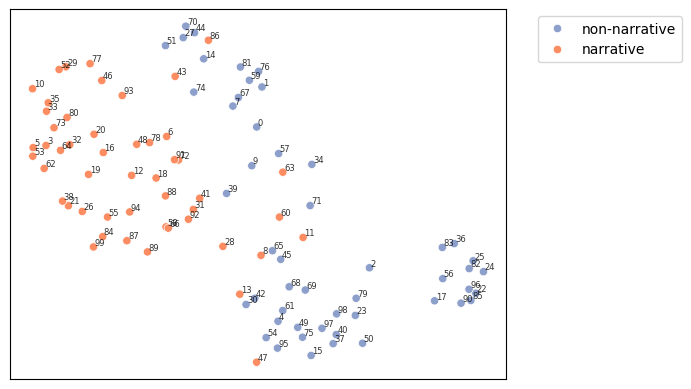

In [13]:
# Now plot the embeddings
plot_umap_embeddings(narrativity_umap_embeddings, narrativity_labels)

We can very clearly see that the classes cluster together&mdash;narrative texts (represented as blue dots) are generally on one side of the image and non-narrative texts (orange dots) are on the other. The embeddings capture differences between narrative and non-narrative texts.

Let's look at individual texts now. Each dot is annotated with its index in small gray text. We can see that there are some outlier documents. For example, documents 11 and 47 is categorized as narrative, but it is surrounded by non-narrative text. What text does this document contain? What do the most-similar documents to it look like?

The following function uses the cosine similarity of the document embeddings to rank all the other embeddings by similarity and print out the three documents that are most similar. 

In [14]:
# Print out a document and its three closest neighbors
def print_neighbors(text_idx):
  print(f'Query text: {narrativity_labels[text_idx]}')
  print(textwrap.fill(narrativity_texts[text_idx][:512]))
  print()
  # The text embedding is the row in the embeddings matrix
  # with the same id as the document
  this_embedding = narrativity_embeddings[text_idx, :]
  # Get similarities by taking the dot product between the embeddings matrix
  # and the embedding we care about
  cosine_similarities = np.dot(narrativity_embeddings, this_embedding)
  # Sort the similarities in descending order
  ordered_idxs = np.argsort(cosine_similarities)[::-1]
  # Cosine similarity with itself is always near 1
  assert(ordered_idxs[0] == text_idx)
  for num, idx in enumerate(ordered_idxs[1:4]):
    print(f'Nearest neighbor {num}: {narrativity_labels[idx]}, {cosine_similarities[idx]:.4f} cosine similarity')
    print(textwrap.fill(narrativity_texts[idx][:512]))
    print()


In [15]:
# Print the most similar documents to document 11
print_neighbors(text_idx=11)

Query text: narrative
Fresher, richer, more data-driven, they are the quants of the
philanthropic world. They want to improve entire sectors such as
education and create institutions where none existed, and they want to
do everything in a precisely measurable way. The Credit Suisse poll,
which was skewed to the high-tech sector, found that 44 percent of
them wanted to affect change within ten years—a far cry from the days
of Carnegie and Rockefeller, whose largess is still being felt. (Only
15 percent thought of their philanthro

Nearest neighbor 0: non-narrative, 0.5467 cosine similarity
There is no support in the statutory language or legislative history
for expansion of § 12(1) primary liability beyond persons who pass
title and persons who ""offer,"" including those who ""solicit""
offers. Indeed, § 12's failure to impose express liability for mere
participation in unlawful sales transactions suggests that Congress
did not intend that the section impose liability on participants
co

Document 11 is a narrative about "the quants of the
philanthropic world". The three most similar documents are all categorized as non-narrative. Perhaps the subject matter of this document is what makes it more similar to these non-narrative texts.

Let's look at an example of a solidly non-narrative text, number 22:

In [16]:
print_neighbors(text_idx=22)

Query text: non-narrative
In this paper, an optical pressure-sensitive membrane based on plasmon
resonance absorption has been designed, fabricated, and demonstrated.
The membrane utilizes plasmon resonance on a gold island film embedded
in a polydimethylsiloxane (PDMS) layers, and the shift of the resonant
wavelength was used as an indicator of pressure-induced strain of the
membrane. The membrane with total thickness of 100 mu m was prepared
with spin-coating of PDMS and vacuum evaporation of gold island film
with the nominal thic

Nearest neighbor 0: non-narrative, 0.5844 cosine similarity
Ion exchange chromatography is a powerful and ubiquitous unit
operation in the purification of therapeutic proteins. However, the
performance of an ion-exchange process depends on a complex
interrelationship between several parameters, such as protein
properties, mobile phase conditions, and chromatographic resin
characteristics. Consequently, batch variations of ion exchange resins
play a signifi

And a narrative text, number 5:

In [17]:
print_neighbors(text_idx=5)

Query text: narrative
(OK, I probably didn't say DAMN! ) Anyway I walked over to the fridge,
grabbed my cup and took a swig. "EGH! Tomato Juice! " I pulled the
little lid off of the cup and sure enough my cup was now half filled
with Tomato Juice.

Nearest neighbor 0: narrative, 0.5337 cosine similarity
From the sign we found out that it was an unused mausoleum. I tell her
that I'm super uncomfortable and want to leave. She says "yeah, ok".
Finally! I thought.

Nearest neighbor 1: narrative, 0.5243 cosine similarity
Out of nowhere, this strange voice from the middle of the room wakes
me up - a deep, male, back-of-the-throat kind of rumble, like a
demon's voice in some bad horror movie. It spoke for a few seconds in
some unrecognizable language and then stopped. I quickly turned around
to see what it was. Nothing. Nothing but my roommate sitting up in
bed, also wondering what the fuck just happened.

Nearest neighbor 2: narrative, 0.5025 cosine similarity
What else could I do? I guess I

We've now seen how the distinction between narrative and non-narrative text is captured by document embeddings. We've used embedding similarity to examine outliers in each category as well as more typical examples from each category. 

### Retrieval
This is interesting, but you should also know that, outside of a humanities and social science research setting, these embedding models are often used for *retrieval*: given some query text, we want to *retrieve* documents that are most similar to our query. Let's simulate that process quickly:

In [18]:
from numpy.typing import ArrayLike # Sometimes type annotations are nice


def retrieve_with_query(
        query: str,                # Our query, a string
        model: SentenceTransformer,# Model to embed query
        embeddings: ArrayLike,     # Embeddings we want to compare to query, generated by model earlier
        df: pd.DataFrame,          # DataFrame of texts used to generate embeddings
        k: int = 5                 # Number of top matches to retrieve
        ) -> None:
    assert embeddings.shape[0] == len(df)     
    query_emb = model.encode(query)        # Generate embedding of query
    sims = query_emb @ embeddings.T        # Get similarity between query and all embeddings
    topk = np.argsort(-sims)[:k]           # Sort embedding indices by decreasing value of 
                                           #    similarity(query, embedding) 
    df_slice = df.iloc[topk].copy()        # Get texts, labels, genres and scores back out
    df_slice["score"] = sims[topk]
    print(f"Mean similarity score: {sims.mean()}") # Just for reference
    return df_slice


In [19]:
retrieve_with_query("a spooky story",
                    model, 
                    narrativity_embeddings, 
                    narrativity_df
                    )

Mean similarity score: 0.4616110324859619


,label,genre,text,score
51,non-narrative,BREVIEW,"But on the other side, the side on which Emma ...",0.619157
53,narrative,REDDIT,"Out of nowhere, this strange voice from the mi...",0.614320
73,narrative,MEM,“I just met the old woman who lived here befor...,0.599507
19,narrative,REDDIT,Usually we only get dark clouds and the North ...,0.588503
93,narrative,FLASH,glancing into that abandoned place you wouldn’...,0.578587


In [20]:
retrieve_with_query("supreme court legal argument", 
                    model, 
                    narrativity_embeddings, 
                    narrativity_df)

Mean similarity score: 0.46744251251220703


,label,genre,text,score
65,non-narrative,SCOTUS,While early cases suggest that there is an unr...,0.680544
45,non-narrative,SCOTUS,Although religious groups benefit from access ...,0.674390
95,non-narrative,SCOTUS,"Holly Farms argues, and the dissent agrees, po...",0.657483
4,non-narrative,SCOTUS,"Petitioner makes contentions, with respect to ...",0.656922
68,non-narrative,SCOTUS,[16] Certain jurisdictional arguments that ha...,0.651280


In [21]:
# what happens if we search for something that's probably not in the data? Like some code?
retrieve_with_query("assert embeddings.shape[0] == len(df)     \
    query_emb = model.encode(query)        # Generate embedding of query \
    sims = query_emb @ embeddings.T        # Get similarity between query and all embeddings \
    topk = np.argsort(-sims)[:k]           # Sort embedding indices by decreasing value of \
                                           #    similarity(query, embedding)",
                    model, 
                    narrativity_embeddings, 
                    narrativity_df
                    )

Mean similarity score: 0.39071619510650635


,label,genre,text,score
24,non-narrative,ABSTRACT,Busulfan (Bu) is commonly used in myeloablativ...,0.509072
0,non-narrative,APHORISM,"The outrage over atrocities decreases, the mor...",0.502028
82,non-narrative,ABSTRACT,Ion exchange chromatography is a powerful and ...,0.498497
96,non-narrative,ABSTRACT,Spectrophotometric analysis was applied to che...,0.473838
34,non-narrative,ABSTRACT,While digital technologies were initially seen...,0.471241


When we search for things that are in our dataset, we can see that we get reasonable results. However, if you use these models for retrieval, you need to keep in mind that similarity scores don't always make intuitive sense. You'll always get a score between two embeddings, but a score of .5 definitely doesn't mean that the query is 50% related to the retrieved passage, as we can see above. There are a number of engineering approaches for addressing retrieval using these models.

## Poetry dataset

We're going to use a dataset of poems to ask the same questions in another context.
We'll also see some of the limitations of document embeddings.

**Questions:**

1. How distinct are poems from the 19th and 20th centuries?

2. Given a specific poem, what do similar poems look like?

**Dataset**: We are going to use the dataset of c. 30,000 public domain poems used in the previous lecture on word similarities.

First, load the dataset and limit it to poems from the 19th and 20th centuries. We're going to just take the first 400 poems from it so the dataset is small enough for us to quickly get the embeddings.

In [22]:
url = "https://raw.githubusercontent.com/melaniewalsh/BERT-4-Humanists/main/data/public-domain-poetry.csv"
poetry_df = pd.read_csv(url, encoding='utf-8')

# Only select poems from the 19th and 20th centuries
poetry_df = poetry_df.loc[poetry_df['period'].isin(['19th Century', '20th Century'])]
# Reindex the rows' indices
poetry_df = poetry_df.reset_index(drop=True)
# Subsample poems so it does not take too long to get embeddings
poetry_df = poetry_df.head(400)
# Print the first 10 poems
poetry_df.head(10)

,author,title,text,lifespan,birth_year,death_year,link,period
0,A. R. Ammons,Crowride,"When the crow\r\nlands, the\r\ntip of the spru...","February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/cro...,20th Century
1,A. R. Ammons,Cut The Grass,The wonderful workings of the world: wonderful...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/cut...,20th Century
2,A. R. Ammons,In Memoriam Mae Noblitt,"This is just a place:\r\nwe go around, distanc...","February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/in-...,20th Century
3,A. R. Ammons,When I Was Young The Silk,When I was young the silk\r\nof my mind\r\nhar...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/whe...,20th Century
4,A. R. Ammons,An Improvisation For Angular Momentum,"Walking is like\r\nimagination, a\r\nsingle st...","February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/an-...,20th Century
5,A. R. Ammons,Rivulose,"You think the ridge hills flowing, breaking\r\...","February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/riv...,20th Century
6,A. R. Ammons,After Yesterday,After yesterday\r\nafternoon's blue\r\nclouds ...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/aft...,20th Century
7,A. R. Ammons,Poetics,I look for the way\r\nthings will turn\r\nout ...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/poe...,20th Century
8,A. R. Ammons,Weathering,A day without rain is like\r\na day without su...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/wea...,20th Century
9,A. R. Ammons,Greeting Verses,What do I find right at the center of my inter...,"February 18, 1926-February 25, 2001",1926.0,2001.0,http://public-domain-poetry.com/a-r-ammons/gre...,20th Century


Poems by several authors are in this sample of the poetry dataset. Here's a list of the unique authors:

In [23]:
set(poetry_df['author'])

{'A. R. Ammons',
 'Abijah M. Ide',
 'Abram Joseph Ryan',
 'Ada Langworthy Collier',
 'Adam Bernard Mickiewicz',
 'Adam Lindsay Gordon',
 'Alan Alexander Milne',
 'Alan L. Strang',
 'Alan Seeger',
 'Albert Bigelow Paine',
 'Aldous Leonard Huxley',
 'Alfred Edward Housman'}

Get the embeddings and perform dimensionality reduction with UMAP:

In [24]:
poetry_texts = poetry_df['text'].tolist()
poetry_labels = poetry_df['period'].tolist()
# Get the embeddings
poetry_embeddings = model.encode(poetry_texts)
# Run UMAP for dimensionality reduction
reducer = umap.UMAP()
poetry_umap_embeddings = reducer.fit_transform(poetry_embeddings)

Now plot the two-dimensional representation of the embeddings, just like we did with the narrativity dataset:

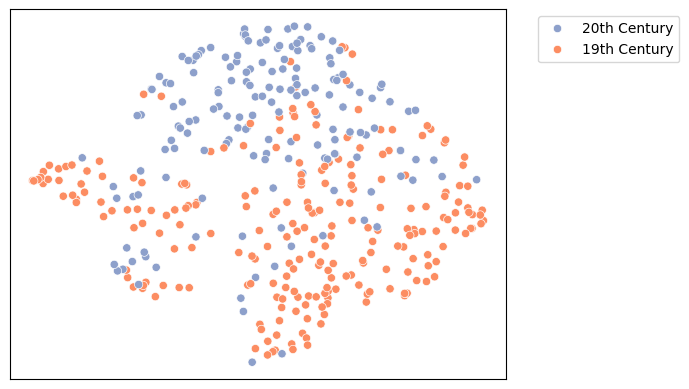

In [25]:
# Use the same function we created for plotting above
plot_umap_embeddings(poetry_umap_embeddings, poetry_labels, annotate_idxs=False)

The two categories are much more intermingled here than they were for narrative vs. non-narrative. It's much harder to identify 19th century vs 20th century poems from these embeddings.

We can also explore these poems by choosing a poem and examining which poems are most similar according to the embedding similarity, just like we did to examine the narrative outliers. Let's look at poem 0 and 100, chosen arbitrarily.

In [26]:
# Print a poem's title and author
def print_poem(df, idx):
  row = df.iloc[idx]
  print(f"{row['title']} by {row['author']} ({row['lifespan']}):")
  print(row['text'].replace('\r\n', ' '))
  print()

# Take as input the index of a poem, and print the nearest neighbors in the
# embedding space.
def print_closest_poems(poem_idx):
  # Get this poem's embedding
  poem_embedding = poetry_embeddings[poem_idx, :]
  # Get cosine similarities with all the other poem embeddings
  cosine_similarities = np.dot(poetry_embeddings, poem_embedding)
  # Sort the poems in descending order by similarity
  ordered_poem_idxs = np.argsort(cosine_similarities)[::-1]
  # A vector's cosine similarity with itself is always 1,
  # so it will be the most similar vector to itself
  assert(ordered_poem_idxs[0] == poem_idx)
  print_poem(poetry_df, poem_idx)
  for num, idx in enumerate(ordered_poem_idxs[1:4]):
    print(f'Nearest neighbor {num}: {poetry_labels[idx]}, {cosine_similarities[idx]:.4f} cosine similarity')
    print_poem(poetry_df, idx)

In [27]:
# Pick a poem, find closest poems
print_closest_poems(poem_idx=0)

Crowride by A. R. Ammons (February 18, 1926-February 25, 2001):
When the crow lands, the tip of the sprung spruce
 bough weighs so low, the system so friction-free,
 the bobbing lasts way past any interest in the subject.

Nearest neighbor 0: 19th Century, 0.4655 cosine similarity
Sea Dreamings by Abram Joseph Ryan (August 15, 1839 - April 22, 1886):
To-day a bird on wings as white as foam That crests the blue-gray wave, With the vesper light upon its breast, flew home Seaward. The God who gave To the birds the virgin-wings of snow Somehow telleth them the ways they go.
 Unto the Evening went the white-winged bird -- Gray clouds hung round the West -- And far away the tempest's tramp was heard. The bird flew for a rest Away from the grove, out to the sea -- Is it only a bird's mystery?
 Nay! nay! lone bird! I watched thy wings of white That cleft thy waveward way -- Past the evening and swift into the night, Out of the calm, bright day -- And thou didst teach me, bird of the sea, More 

In [28]:
print_closest_poems(poem_idx=100)

The Rosary of My Tears by Abram Joseph Ryan (August 15, 1839 - April 22, 1886):
Some reckon their age by years,  Some measure their life by art; But some tell their days by the flow of their tears,  And their lives by the moans of their heart.
 The dials of earth may show  The length, not the depth, of years, Few or many they come, few or many they go,  But time is best measured by tears.
 Ah! not by the silver gray  That creeps thro' the sunny hair, And not by the scenes that we pass on our way,  And not by the furrows the fingers of care
 On forehead and face have made.  Not so do we count our years; Not by the sun of the earth, but the shade  Of our souls, and the fall of our tears.
 For the young are ofttimes old,  Though their brows be bright and fair; While their blood beats warm, their hearts are cold --  O'er them the spring -- but winter is there.
 And the old are ofttimes young,  When their hair is thin and white; And they sing in age, as in youth they sung,  And they laugh, 

For both of these poems, the other poems with the most similar embeddings mostly include those by the same author! Now, we can't yet be sure why this is the case; we're working with a small dataset that has a *lot* of poems by each of the writers that we examined. But we have a preliminary suggestion that, when representing poems with document embeddings, authorship may account for a meaningful part of the differences between embeddings. This does not mean that these embeddings are useless, but we (may) have identified an important part of what embedding similarity recovers in this context.

These embeddings represent author well, while it is much harder to tell poems from different periods apart.

In [ ]:
poetry_df.period.describe()

Here's a fun visualization we can do, where we can visualize how similar poems are to a query with a UMAP. What sort of topics do you expect to be able to find here? 

<Axes: xlabel='x', ylabel='y'>

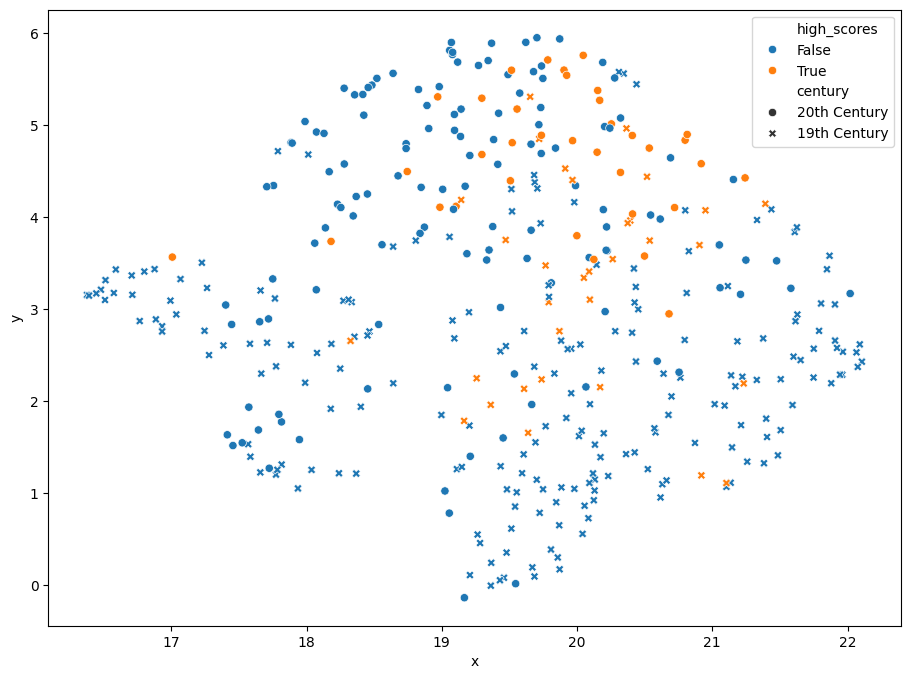

In [29]:
from sklearn.preprocessing import StandardScaler


query = "natural beauty, pastoral, bucolic, mountain, forest, countryside"

high_scores = StandardScaler().fit_transform(           # 1.0 if greater than 1 std from the mean
    (model.encode(query) @ poetry_embeddings.T)[:,None]
    ).squeeze() > 1.0


poetry_umap_df = pd.DataFrame({"x": poetry_umap_embeddings[:, 0],
                               "y": poetry_umap_embeddings[:, 1], 
                               "high_scores": high_scores, 
                               "century": poetry_df.period})


plt.subplots(figsize=(11, 8))

sns.scatterplot(
    data=poetry_umap_df,
    x="x",
    y="y",
    hue="high_scores",
    style="century"
)